<a href="https://colab.research.google.com/github/HST0077/HYOTC/blob/main/CDS%26HazardRate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

# (단위: %, 출처: S&P Global Ratings Research 표에 나온 값)
# 누적 부도확률로 1981년부터 2020년 자료를 바탕으로 추정되었음

data = {
    1:  {"AAA": 0.00, "AA": 0.02, "A": 0.05, "BBB": 0.16, "BB": 0.63, "B": 3.34, "CCC/C": 28.30},
    2:  {"AAA": 0.03, "AA": 0.06, "A": 0.13, "BBB": 0.43, "BB": 1.93, "B": 7.80, "CCC/C": 38.33},
    3:  {"AAA": 0.13, "AA": 0.11, "A": 0.22, "BBB": 0.75, "BB": 3.46, "B": 11.75, "CCC/C": 43.42},
    4:  {"AAA": 0.24, "AA": 0.21, "A": 0.33, "BBB": 1.14, "BB": 4.99, "B": 14.89, "CCC/C": 46.36},
    5:  {"AAA": 0.34, "AA": 0.30, "A": 0.46, "BBB": 1.54, "BB": 6.43, "B": 17.35, "CCC/C": 48.58},
    7:  {"AAA": 0.51, "AA": 0.49, "A": 0.76, "BBB": 2.27, "BB": 8.89, "B": 20.99, "CCC/C": 50.75},
    10: {"AAA": 0.70, "AA": 0.70, "A": 1.20, "BBB": 3.24, "BB": 11.64, "B": 24.62, "CCC/C": 52.76},
    15: {"AAA": 0.90, "AA": 0.99, "A": 1.84, "BBB": 4.54, "BB": 14.65, "B": 28.24, "CCC/C": 54.76},
}

df = pd.DataFrame(data)
df.index.name = "Rating"
df.columns.name = "Time Horizon (years)"
df

Time Horizon (years),1,2,3,4,5,7,10,15
Rating,,,,,,,,
AAA,0.00,0.03,0.13,0.24,0.34,0.51,0.70,0.90
AA,0.02,0.06,0.11,0.21,0.30,0.49,0.70,0.99
A,0.05,0.13,0.22,0.33,0.46,0.76,1.20,1.84
BBB,0.16,0.43,0.75,1.14,1.54,2.27,3.24,4.54
BB,0.63,1.93,3.46,4.99,6.43,8.89,11.64,14.65
B,3.34,7.80,11.75,14.89,17.35,20.99,24.62,28.24
CCC/C,28.30,38.33,43.42,46.36,48.58,50.75,52.76,54.76


In [11]:
df.columns.tolist()

[1, 2, 3, 4, 5, 7, 10, 15]

In [3]:
# ------------------------------
#    Incremental (interval) default probability for the given tenors
#    inc(0-1) = cum(1)
#    inc(1-2) = cum(2) - cum(1), ...
# ------------------------------
tenors = sorted(df.columns.tolist())
df_cum = df[tenors].copy()              # %
df_inc = df_cum.diff(axis=1)            # % differences
df_inc[tenors[0]] = df_cum[tenors[0]]   # first interval from 0 to first tenor

# Rename columns to interval labels like "0-1Y", "1-2Y", ...
interval_cols = []
prev = 0
for t in tenors:
    interval_cols.append(f"{prev}-{t}Y")
    prev = t
df_inc.columns = interval_cols
df_inc.index.name = "Rating"
df_inc.columns.name = "Interval"
df_inc

Interval,0-1Y,1-2Y,2-3Y,3-4Y,4-5Y,5-7Y,7-10Y,10-15Y
Rating,,,,,,,,
AAA,0.00,0.03,0.10,0.11,0.10,0.17,0.19,0.20
AA,0.02,0.04,0.05,0.10,0.09,0.19,0.21,0.29
A,0.05,0.08,0.09,0.11,0.13,0.30,0.44,0.64
BBB,0.16,0.27,0.32,0.39,0.40,0.73,0.97,1.30
BB,0.63,1.30,1.53,1.53,1.44,2.46,2.75,3.01
B,3.34,4.46,3.95,3.14,2.46,3.64,3.63,3.62
CCC/C,28.30,10.03,5.09,2.94,2.22,2.17,2.01,2.00


In [20]:
# 한글 폰트 설치
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1) 폰트 파일 경로 (존재하는 걸로 확인됨)
FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 2) Matplotlib 폰트 매니저에 "등록" (중요)
fm.fontManager.addfont(FONT_PATH)

# 3) 등록된 폰트의 정확한 패밀리 이름을 파일에서 다시 읽어옴
font_name = fm.FontProperties(fname=FONT_PATH).get_name()

# 4) rcParams 리셋 후 적용
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False


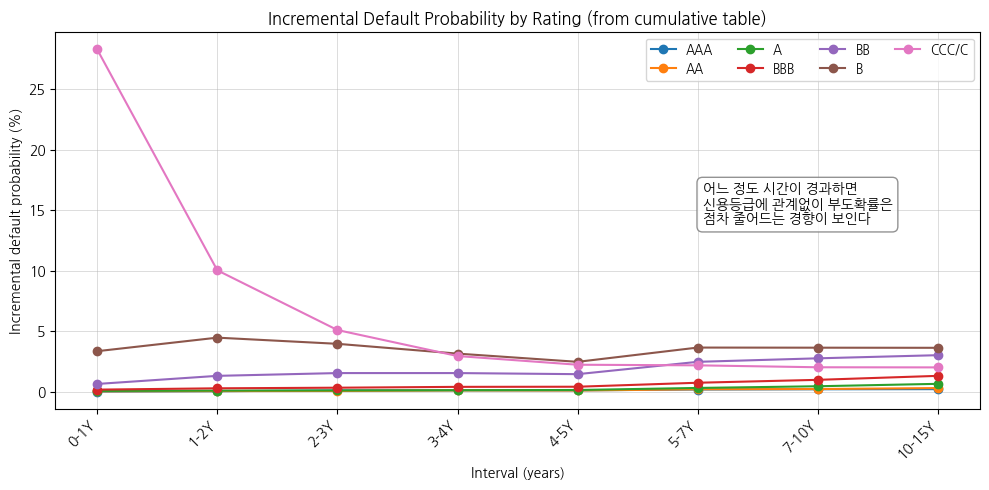

In [26]:
# ------------------------------
#    Plot: each rating as a line across intervals
#    (no explicit color choices)
# ------------------------------
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(interval_cols))

plt.figure(figsize=(10, 5))
for rating in df_inc.index:
    plt.plot(x, df_inc.loc[rating].values, marker="o", label=rating)

plt.xticks(x, interval_cols, rotation=45, ha="right")
plt.xlabel("Interval (years)")
plt.ylabel("Incremental default probability (%)")
plt.title("Incremental Default Probability by Rating (from cumulative table)")
plt.grid(True, linewidth=0.5, alpha=0.6)
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()

ax = plt.gca()

msg = "어느 정도 시간이 경과하면\n신용등급에 관계없이 부도확률은\n점차 줄어드는 경향이 보인다"

ax.text(
    0.7, 0.6, msg,                 # (x,y) 축 좌표(0~1) 기준
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="gray")
)

plt.show()

#구간 $[0,t]$에서 어떤 기업이 부도가 나지 않은 상황에서 $[t,\,t+\Delta t]$ 사이에 부도가 날 확률의 (순간) 강도를 hazard rate $\lambda(t)$라고 정의한다.앞 문제에서 사용한 `df`(누적 부도확률 테이블)를 바탕으로 각 등급에서의 구간별 hazard rate를 추정해 보아라.

$V(t)$를 시점 $t$까지 살아 있을 확률이라고 정의하면 $V(t)-V(t+\Delta t)$는 $[t,t+\Delta t]$ 사이에 부도날 확률이라고 볼 수 있다.  
위 문제의 정의에 의하면 아래와 같이 hazard rate를 다시 정의할 수 있다.

$
\lambda(t)\Delta t
=\frac{V(t)-V(t+\Delta t)}{V(t)}
\;\Rightarrow\;
\frac{V(t)-V(t+\Delta t)}{\Delta t}
=\lambda(t)V(t)
$

$
\lim_{\Delta t\to 0}\frac{V(t)-V(t+\Delta t)}{\Delta t}
=-\frac{dV(t)}{dt}
=\lambda(t)V(t)
\;\Rightarrow\;
V(t)=\exp\!\left(-\int_{0}^{t}\lambda(s)\,ds\right)
$

$Q(t)$를 $[0,t]$에서 부도 확률이라고 정의하면, $Q(t)=1-V(t)$라고 할 수 있고, 아래와 같이 근사시킬 수 있다.

$Q(t)=1-e^{-\int_{0}^{t}\lambda(s)\,ds}=1-e^{-\bar{\lambda}t}$

$
\overline{\lambda}_{[t_1,t_2]}
= -\frac{\ln\left(\frac{1-Q(t_2)}{1-Q(t_1)}\right)}{t_2-t_1}
= -\frac{\ln\left(\frac{V(t_2)}{V(t_1)}\right)}{t_2-t_1}
$

In [27]:
import numpy as np
import pandas as pd

# ============================================================
# 0) (예시) 누적 부도확률표 df 만들기 (단위: %)
#    이미 df가 있으면 이 블록은 건너뛰면 됨
# ============================================================
data = {
    1:  {"AAA": 0.00, "AA": 0.02, "A": 0.05, "BBB": 0.16, "BB": 0.63, "B": 3.34, "CCC/C": 28.30},
    2:  {"AAA": 0.03, "AA": 0.06, "A": 0.13, "BBB": 0.43, "BB": 1.93, "B": 7.80, "CCC/C": 38.33},
    3:  {"AAA": 0.13, "AA": 0.11, "A": 0.22, "BBB": 0.75, "BB": 3.46, "B": 11.75, "CCC/C": 43.42},
    4:  {"AAA": 0.24, "AA": 0.21, "A": 0.33, "BBB": 1.14, "BB": 4.99, "B": 14.89, "CCC/C": 46.36},
    5:  {"AAA": 0.34, "AA": 0.30, "A": 0.46, "BBB": 1.54, "BB": 6.43, "B": 17.35, "CCC/C": 48.58},
    7:  {"AAA": 0.51, "AA": 0.49, "A": 0.76, "BBB": 2.27, "BB": 8.89, "B": 20.99, "CCC/C": 50.75},
    10: {"AAA": 0.70, "AA": 0.70, "A": 1.20, "BBB": 3.24, "BB": 11.64, "B": 24.62, "CCC/C": 52.76},
    15: {"AAA": 0.90, "AA": 0.99, "A": 1.84, "BBB": 4.54, "BB": 14.65, "B": 28.24, "CCC/C": 54.76},
}
df = pd.DataFrame(data)
df.index.name = "Rating"
df.columns.name = "Time Horizon (years)"


# ============================================================
# 1) 누적부도확률표(df) -> 구간별 평균 hazard rate 추정 함수
# ============================================================
# 함수 정의에서 데이터프레임을 입력받아서, 출력도 데이터프레임으로 한다는 것을 암시함
def estimate_piecewise_hazard_from_cum_pd(df_cum_pct: pd.DataFrame) -> pd.DataFrame:
    """
    df_cum_pct: 누적 부도확률(단위: %) DataFrame
                index=Rating, columns=tenors(예: 1,2,3,4,5,7,10,15)

    가정:
    - 각 구간 (t_{i-1}, t_i]에서 hazard rate λ는 상수(piecewise constant)
    - 생존확률 V(t)=S(t)=1-Q(t)=1-CumPD(t)

    이때 구간별 평균 hazard:
      λ_i = - ln( V(t_i) / V(t_{i-1}) ) / (t_i - t_{i-1})
          = - ln( (1-CumPD(t_i)) / (1-CumPD(t_{i-1})) ) / Δt

    반환:
    - hazards: index=Rating
               columns 예: '0-1Y','1-2Y','2-3Y','3-4Y','4-5Y','5-7Y','7-10Y','10-15Y'
               값은 "연 단위 hazard (per year)"
    """
    # 1) 만기(tenor) 정렬
    tenors = sorted([float(c) for c in df_cum_pct.columns])
    df = df_cum_pct.copy()
    df.columns = tenors
    df = df[tenors]

    # 2) 누적 PD(%) -> 소수, 생존확률 V(t)=1-Q(t)
    # 아래 clip()함수
      # 0.0보다 작은 값(예: -0.2) → 0.0으로 바뀜
      # 0.999999보다 큰 값(예: 1.0, 1.2) → 0.999999로 바뀜
    Q = (df / 100.0).clip(0.0, 0.999999)  # 100%에 아주 가까울 수 있어 안전장치
    V = 1.0 - Q                           # survival

    # 3) 구간별 hazard 계산
    hazards = pd.DataFrame(index=df.index)
    prev_t = 0.0
    prev_V = pd.Series(1.0, index=df.index)  # V(0)=1

    for t in tenors:
        dt = t - prev_t
        curr_V = V[t]

        # 비율이 0에 가까우면 log에서 터지므로 clip
        ratio = (curr_V / prev_V).clip(1e-15, 1.0)

        lam = -np.log(ratio) / dt  # per-year hazard on (prev_t, t]
        hazards[f"{int(prev_t)}-{int(t)}Y"] = lam

        prev_t = t
        prev_V = curr_V

    hazards.index.name = "Rating"
    hazards.columns.name = "Interval hazard (per year)"
    return hazards


# ============================================================
# 2) 실행: df -> 구간별 hazard rate
# ============================================================
haz_df = estimate_piecewise_hazard_from_cum_pd(df)

print("=== 구간별 평균 hazard rate (per year) ===")
print(haz_df)

print("\n[예시] CCC/C 등급의 구간별 hazard:")
print(haz_df.loc["CCC/C"])


=== 구간별 평균 hazard rate (per year) ===
Interval hazard (per year)      0-1Y      1-2Y      2-3Y      3-4Y      4-5Y  \
Rating                                                                         
AAA                        -0.000000  0.000300  0.001001  0.001102  0.001003   
AA                          0.000200  0.000400  0.000500  0.001002  0.000902   
A                           0.000500  0.000801  0.000902  0.001103  0.001305   
BBB                         0.001601  0.002708  0.003219  0.003937  0.004054   
BB                          0.006320  0.013169  0.015724  0.015975  0.015272   
B                           0.033971  0.047240  0.043786  0.036229  0.029330   
CCC/C                       0.332679  0.150693  0.086142  0.053361  0.042268   

Interval hazard (per year)      5-7Y     7-10Y    10-15Y  
Rating                                                    
AAA                         0.000854  0.000637  0.000403  
AA                          0.000954  0.000704  0.000585  
A    

# Hazard rate가 2% p.a. 으로 고정되어 있다고 할 때, 1년 이내 부도날 확률, 1년과 2년 사이에 부도날 확률, 2년과 3년 사이에 부도날 확률, 3년과 4년 사이에 부도날 확률, 4년과 5년 사이에 부도날 확률을 각각 구하여 보아라.

In [28]:
import numpy as np

V1=np.exp(-0.02)
V1

np.float64(0.9801986733067553)

In [29]:
for t in range(1,6):
  print(f'V({t}):',np.exp(-0.02*t))

V(1): 0.9801986733067553
V(2): 0.9607894391523232
V(3): 0.9417645335842487
V(4): 0.9231163463866358
V(5): 0.9048374180359595


In [30]:
import numpy as np
import pandas as pd

# hazard rate (per annum)
lam = 0.02  # 2% p.a.

def survival(t: float) -> float:
    """Survival probability V(t) = P(no default by t)"""
    return np.exp(-lam * t)

def default_prob_between(t1: float, t2: float) -> float:
    """Unconditional default probability P(t1 < τ <= t2)"""
    return survival(t1) - survival(t2)

# 구간별(무조건부) 부도확률 계산: [0,1], (1,2], (2,3], (3,4], (4,5]
intervals = [(0,1), (1,2), (2,3), (3,4), (4,5)]

rows = []
for t1, t2 in intervals:
    p = default_prob_between(t1, t2)
    rows.append({
        "Interval": f"{t1}-{t2} year",
        "Default Prob (decimal)": p,
        "Default Prob (%)": 100 * p
    })

df = pd.DataFrame(rows)
df


,Interval,Default Prob (decimal),Default Prob (%)
0,0-1 year,0.019801,1.980133
1,1-2 year,0.019409,1.940923
2,2-3 year,0.019025,1.902491
3,3-4 year,0.018648,1.864819
4,4-5 year,0.018279,1.827893


# **CDS Premium Calculation**

# 	(CDS 프리미엄) Hazard rate가 2% p.a. 로 고정되어 있는 어떤 회사의 부도는 매년 6월말에 발생할 수 있으며, 부도가 나지 않으면 명목금액 $1에 대한 보증율 s% p.a. 를 해당 년도의 말에 지불한다고 한다. 무위험 이자율이 연속복리로 5% p.a. 이라고 하고, 회수율(recovery rate)을 40%라고 할 때, CDS 프리미엄 s를 구하여라.

In [31]:
# Survival Probs
V=np.array([np.exp(-0.02*t) for t in range(1,6)])
V

array([0.98019867, 0.96078944, 0.94176453, 0.92311635, 0.90483742])

In [32]:
# Unconditional Default Probs and Survival Probs

df_new=pd.DataFrame(data={'Time(yrs)':[1,2,3,4,5],'Probs of Survival to Year End':V,'Probs of Default During Year':df.iloc[:,1]})
df_new

,Time(yrs),Probs of Survival to Year End,Probs of Default During Year
0,1,0.980199,0.019801
1,2,0.960789,0.019409
2,3,0.941765,0.019025
3,4,0.923116,0.018648
4,5,0.904837,0.018279


In [33]:
import numpy as np
import pandas as pd
import sympy as sp

# ----------------------------
# 입력값
# ----------------------------
lam = 0.02   # hazard rate (2% p.a.)
r   = 0.05   # continuous comp. rate (5% p.a.)
T   = 5

s = sp.Symbol("s")  # <-- 핵심: 문자열 "s"가 아니라 '기호' s

# ----------------------------
# 테이블 계산
# ----------------------------
times = np.arange(1, T + 1)

# 생존확률, 할인계수 (숫자)
survival = np.exp(-lam * times)
dfactor  = np.exp(-r * times)

# PV 계수(숫자): survival * discount factor
pv_coeff = survival * dfactor

# sympy로 바꿔서 "계수 * s" 형태의 수식으로 만들기
pv_expr = [sp.Float(c, 10) * s for c in pv_coeff]       # PV of Expected Payment
exp_expr = [sp.Float(c, 10) * s for c in survival]      # Expected Payment

df_table = pd.DataFrame({
    "Time (years)": times,
    "Probability of Survival": np.round(survival, 4),
    "Expected Payment": exp_expr,         # <- sympy expression
    "Discount Factor": np.round(dfactor, 4),
    "PV of Expected Payment": pv_expr,    # <- sympy expression
})

df_table

,Time (years),Probability of Survival,Expected Payment,Discount Factor,PV of Expected Payment
0,1,0.9802,0.9801986733*s,0.9512,0.9323938199*s
1,2,0.9608,0.9607894392*s,0.9048,0.8693582354*s
2,3,0.9418,0.9417645336*s,0.8607,0.810584246*s
3,4,0.9231,0.9231163464*s,0.8187,0.7557837415*s
4,5,0.9048,0.904837418*s,0.7788,0.7046880897*s


In [34]:
# 칼럼의 총합 계산
df_table.sum()

,0
Time (years),15
Probability of Survival,4.7107
Expected Payment,4.71070641*s
Discount Factor,4.3142
PV of Expected Payment,4.072808132*s


In [35]:
import numpy as np
import pandas as pd

# =========================
# 입력
# =========================
notional = 1.0     # notional principal = $1
R = 0.4            # recovery rate
lam = 0.02         # hazard rate (2% p.a., 상수)
r = 0.05           # 무위험이자율 (연속복리 5%)
N = 5              # 1~5년 구간

# =========================
# 1) 연간 부도확률(무조건부) 계산
#    P(default in (k-1, k]) = V(k-1) - V(k)
#    V(t) = exp(-lam * t)
# =========================
k = np.arange(1, N + 1)                  # 1,2,3,4,5 (연도 경계)
V_prev = np.exp(-lam * (k - 1))          # V(0), V(1), ... V(4)
V_curr = np.exp(-lam * k)                # V(1), V(2), ... V(5)
pd_interval = V_prev - V_curr            # 연간(무조건부) 부도확률

# 매년 6개월 시점에서 부도 발생한다는 가정에 의한 시점 설정
time_mid = k - 0.5

# =========================
# 2) 기대지급액(보호레그)
#    default 발생 시 (1-R) * notional 지급
#    expected payoff = pd_interval * (1-R) * notional
# =========================
expected_payoff = pd_interval * (1 - R) * notional

# =========================
# 3) 할인계수(연속복리): DF(t) = exp(-r t)
# =========================
discount_factor = np.exp(-r * time_mid)

# =========================
# 4) 기대지급 현재가치
# =========================
pv_expected_payoff = expected_payoff * discount_factor

# =========================
# 5) 표(DataFrame) 만들기 (그림처럼 반올림)
# =========================
df_table_pay = pd.DataFrame({
    "Time (years)": time_mid,
    "Probability of Default": pd_interval,
    "Recovery Rate": R,
    "Expected Payoff ($)": expected_payoff,
    "Discount Factor": discount_factor,
    "PV of Expected Payoff ($)": pv_expected_payoff,
})

# 그림과 비슷하게 소수점 4자리로 표시
df_show = df_table_pay.copy()
for col in ["Time (years)", "Probability of Default", "Recovery Rate",
            "Expected Payoff ($)", "Discount Factor", "PV of Expected Payoff ($)"]:
    df_show[col] = df_show[col].map(lambda x: float(f"{x:.4f}"))

df_show


,Time (years),Probability of Default,Recovery Rate,Expected Payoff ($),Discount Factor,PV of Expected Payoff ($)
0,0.5,0.0198,0.4,0.0119,0.9753,0.0116
1,1.5,0.0194,0.4,0.0116,0.9277,0.0108
2,2.5,0.0190,0.4,0.0114,0.8825,0.0101
3,3.5,0.0186,0.4,0.0112,0.8395,0.0094
4,4.5,0.0183,0.4,0.0110,0.7985,0.0088


In [36]:
df_table_pay.sum()

,0
Time (years),12.500000
Probability of Default,0.095163
Recovery Rate,2.000000
Expected Payoff ($),0.057098
Discount Factor,4.423524
PV of Expected Payoff ($),0.050615


In [37]:
import numpy as np
import pandas as pd
import sympy as sp

# ----------------------------
# 입력값
# ----------------------------
lam = 0.02   # hazard rate (2% p.a.)
r   = 0.05   # cont. comp discount rate (5% p.a.)
N   = 5      # 1~5년

s = sp.Symbol("s")  # <-- sympy 기호

# ----------------------------
# 계산
# ----------------------------
k = np.arange(1, N + 1)          # 1,2,3,4,5
time_mid = k - 0.5               # 0.5, 1.5, 2.5, 3.5, 4.5

# 생존확률 V(t) = exp(-lam t)
V_prev = np.exp(-lam * (k - 1))  # V(0),V(1),...,V(4)
V_curr = np.exp(-lam * k)        # V(1),V(2),...,V(5)

# (k-1, k] 구간 무조건부 부도확률
pd_interval = V_prev - V_curr

# 부도는 연도 중간에 난다고 근사 -> accrued premium ≈ 0.5*s
# 기대 accrued payment = P(default in year k) * 0.5*s
expected_accrual = [sp.Float(0.5 * p, 12) * s for p in pd_interval]

# 할인계수 DF(t_mid) = exp(-r t_mid)
discount_factor = np.exp(-r * time_mid)

# PV of expected accrual payment
pv_expected_accrual = [
    sp.Float(0.5 * p * df, 12) * s
    for p, df in zip(pd_interval, discount_factor)
]

df_accural = pd.DataFrame({
    "Time (years)": time_mid,
    "Probability of Default": np.round(pd_interval, 4),
    "Expected Accrual Payment": expected_accrual,          # sympy 표현
    "Discount Factor": np.round(discount_factor, 4),
    "PV of Expected Accrual Payment": pv_expected_accrual, # sympy 표현
})

df_accural


,Time (years),Probability of Default,Expected Accrual Payment,Discount Factor,PV of Expected Accrual Payment
0,0.5,0.0198,0.00990066334662*s,0.9753,0.00965621509762*s
1,1.5,0.0194,0.00970461707722*s,0.9277,0.0090033952807*s
2,2.5,0.0190,0.00951245278404*s,0.8825,0.00839471011789*s
3,3.5,0.0186,0.00932409359881*s,0.8395,0.00782717583383*s
4,4.5,0.0183,0.00913946417534*s,0.7985,0.00729801037478*s


In [38]:
df_accural.sum()

,0
Time (years),12.5
Probability of Default,0.0951
Expected Accrual Payment,0.047581290982*s
Discount Factor,4.4235
PV of Expected Accrual Payment,0.0421795067048*s


In [39]:
# CDS preimum
from sympy import Eq, solve
premiumleg_pv=0.0421795067048*s+4.072808132*s
protectionleg_pv=0.050615
eqn=premiumleg_pv-protectionleg_pv
solve(eqn,s)

[0.0123001584558663]